# **Data Mining and Machine Learning**
# **Assignment 1** 

#### **Submitted by:**  
### ~ Arushi Marwaha (MDS202512)
### ~ Deepta Basak (MDS202517)

#### **Course:** MSc Data Science 1  
----


## Task 2: Bollywood Movie Success Prediction
---
### Objective: 
To build and compare Decision Tree and Naïve Bayes classifiers to predict whether a movie will be a "Hit" ($Revenue > Budget$) or a "Flop."

## Overall Pipeline

The following steps were performed:

1. Data cleaning and numeric conversion  
2. Target variable creation (Hit/Flop)  
3. Handling missing values  
4. Exploratory data analysis  
5. Feature encoding and scaling  
6. Train–test split (70–30 split with stratification)  
7. Testing multiple Decision Tree depths (3, 5, 7, 10) to select the optimal model  
8. Training the final Decision Tree and Naïve Bayes models  
9. Model evaluation and comparison using accuracy and F1-score  
10. Runtime and computationelling process.ng process.

### Data Loading & Pre-processing
We begin by cleaning the raw dataset. Real-world financial data often contains non-numeric strings; we "coerce" these to ensure mathematical consistency.

## Libraries Used

The following libraries were used in this assignment:

- numpy – used for numerical operations and array handling  
- pandas – used for data loading, cleaning, and preprocessing  
- scikit-learn – used for building and evaluating machine learning models (Decision Tree and Naïve Bayes), data splitting, and performance metrics  
- matplotlib – used for plotting graphs and visualizing the decision tree  
- seaborn – used for improved statistical visualizations such as heatmaps  
- time – used to measure training time of the models  
- sys – used for basic system-level operations  els  

In [163]:
# Importing core libraries
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report,f1_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import time
import seaborn as sns
import sys

#### Loading the dataset

In [164]:
df = pd.read_csv("C:/Users/arush/Desktop/CMI/Semester 2/DMML/Assignment 1/bollywood/Data for repository.csv")



### Numeric Coercion
We converted `Revenue` and `Budget` to numeric types because these columns often contain string errors. This prevents code crashes during mathematical operations.

### Target Definition ($y$)
We defined $y = 1$ if $Revenue > Budget$ (**Hit**) and $y = 0$ otherwise (**Flop**).  
This transforms a general dataset into a **Binary Classification** task suitable for supervised learning.

### Handling Missing Values
We dropped rows where `Revenue` or `Budget` were null.  
A classification model cannot learn the relationship between features and labels if the label itself is missing.

In [165]:
df['Revenue(INR)'] = pd.to_numeric(df['Revenue(INR)'],errors = 'coerce')
df['Budget(INR)'] = pd.to_numeric(df['Budget(INR)'],errors = 'coerce')
df = df.dropna(subset = ['Revenue(INR)','Budget(INR)'])
df['y']=(df['Revenue(INR)']> df['Budget(INR)']).astype(int)

In [166]:
df[['Revenue(INR)','Budget(INR)','y']].head(10)

,Revenue(INR),Budget(INR),y
0,5000000,85000,1
1,15000000,825000,1
2,75000000,56700000,1
3,210000000,4500000,1
4,1000000,1075000,0
5,5000000,170000,1
6,1500000,35000,1
7,15000000,825000,1
8,520000000,1945820000,0
9,180000000,875785000,0


## Dataset Description

The dataset contains 1698 Hindi movies released between 2005–2017.

Attributes include:
- Budget
- Revenue
- Screens
- Genre
- Director
- Lead actors
- Release ine attributes.

##  Exploratory Data Analysis (EDA)
 
To discover patterns, identify anomalies, and validate assumptions before training models.

### Label Noise Audit
By checking films like *Ghajini*, we identified that some major hits are incorrectly labeled as **"Flops"** in the raw data due to unit inconsistencies.  
Documenting this **label noise** is crucial for explaining why the model might not achieve 100% accureased movies.

In [167]:
df.info()  # checking if any value in y is null

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1698 entries, 0 to 1697
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Movie Name          1698 non-null   object
 1   Release Period      1698 non-null   object
 2   Whether Remake      1698 non-null   object
 3   Whether Franchise   1698 non-null   object
 4   Genre               1698 non-null   object
 5   New Actor           1698 non-null   object
 6   New Director        1698 non-null   object
 7   New Music Director  1698 non-null   object
 8   Lead Star           1698 non-null   object
 9   Director            1698 non-null   object
 10  Music Director      1698 non-null   object
 11  Number of Screens   1698 non-null   int64 
 12  Revenue(INR)        1698 non-null   int64 
 13  Budget(INR)         1698 non-null   int64 
 14  y                   1698 non-null   int32 
dtypes: int32(1), int64(3), object(11)
memory usage: 192.5+ KB


In [168]:
print('Target Distribution:\n',df['y'].value_counts())

Target Distribution:
 y
1    1226
0     472
Name: count, dtype: int64


In [169]:
print('\n Financial Summary:\n',df[['Revenue(INR)','Budget(INR)']].describe())


 Financial Summary:
        Revenue(INR)   Budget(INR)
count  1.698000e+03  1.698000e+03
mean   1.501674e+08  2.377287e+08
std    2.434838e+08  6.134398e+08
min    3.250000e+05  7.250000e+03
25%    1.500000e+07  1.150000e+06
50%    5.500000e+07  1.240000e+07
75%    1.900000e+08  1.778325e+08
max    2.100000e+09  8.016120e+09


### Correlation Analysis
We examined the relationship between features such as `Budget` and `Number of Screens` to understand dependencies and potential predictive signals.


In [170]:
print(df[['Revenue(INR)','Budget(INR)','y']].corr())

              Revenue(INR)  Budget(INR)         y
Revenue(INR)      1.000000     0.843446 -0.476381
Budget(INR)       0.843446     1.000000 -0.528386
y                -0.476381    -0.528386  1.000000


In [171]:
#checking if the logic matches the target
df[['Revenue(INR)','Budget(INR)','y']].sort_values(by='Revenue(INR)',ascending=False).head(10)

,Revenue(INR),Budget(INR),y
1240,2100000000,5651020000,0
947,1950000000,8016120000,0
1260,1800000000,3654575000,0
17,1750000000,5243760000,0
946,1700000000,1682350000,1
1379,1650000000,3722315000,0
568,1600000000,2706912500,0
1370,1500000000,3427610000,0
1132,1450000000,3562025000,0
1239,1450000000,5772875000,0


In [172]:
df['y'].value_counts(normalize=True)

y
1    0.722026
0    0.277974
Name: proportion, dtype: float64

In [173]:
df['Profit_ratio']= df['Revenue(INR)']/df['Budget(INR)']
print(df[['Movie Name','Profit_ratio','y']].head(10))

                Movie Name  Profit_ratio  y
0              Golden Boys     58.823529  1
1            Kaccha Limboo     18.181818  1
2         Not A Love Story      1.322751  1
3               Qaidi Band     46.666667  1
4                Chaatwali      0.930233  0
5         Shuttlecock Boys     29.411765  1
6           Dirty Marriage     42.857143  1
7  Future To Bright Hai Ji     18.181818  1
8                  Ghajini      0.267240  0
9         Taare Zameen Par      0.205530  0


In [174]:
print(df[df['Movie Name'] == 'Ghajini'][['Movie Name', 'Revenue(INR)', 'Budget(INR)', 'y']])

  Movie Name  Revenue(INR)  Budget(INR)  y
8    Ghajini     520000000   1945820000  0


In [175]:
print(df[df['Movie Name'] == 'Om Shanti Om'][['Movie Name', 'Revenue(INR)', 'Budget(INR)', 'y']])

        Movie Name  Revenue(INR)  Budget(INR)  y
1369  Om Shanti Om     400000000   1498725000  0


In [176]:
x = df.drop(['Movie Name','Revenue(INR)','y'], axis = 1)
y = df['y']

In [177]:
df.sort_values(by='Budget(INR)',ascending=False).head(10)

,Movie Name,Release Period,Whether Remake,Whether Franchise,Genre,New Actor,New Director,New Music Director,Lead Star,Director,Music Director,Number of Screens,Revenue(INR),Budget(INR),y,Profit_ratio
947,Bahubali 2 - The Conclusion,Holiday,No,Yes,masala,No,No,No,Prabhas,S.S. Rajamouli,M.M. Kreem,3950,1950000000,8016120000,0,0.243260
12,Dangal,Holiday,No,No,drama,No,No,No,Aamir Khan,Nitish Tiwari,Pritam,4250,1320000000,7024750000,0,0.187907
14,PK,Normal,No,No,drama,No,No,No,Aamir Khan,Rajkumar Hirani,Ajay - Atul,3600,1220000000,6160362500,0,0.198040
1248,Bajrangi Bhaijaan,Holiday,No,No,masala,No,No,No,Salman Khan,Kabir Khan,Pritam,4100,1250000000,6039940000,0,0.206956
1239,Sultan,Holiday,No,No,masala,No,No,No,Salman Khan,Ali Abbas Zafar,Vishal - Shekhar,4350,1450000000,5772875000,0,0.251175
1240,Tiger Zinda Hai,Holiday,No,Yes,action,No,No,No,Salman Khan,Ali Abbas Zafar,Vishal - Shekhar,4600,2100000000,5651020000,0,0.371614
17,Dhoom 3,Normal,No,Yes,action,No,No,No,Aamir Khan,Vijay Krishna Acharya,Pritam,3650,1750000000,5243760000,0,0.333730
1378,Chennai Express,Holiday,No,No,masala,No,No,Yes,Shahrukh Khan,Rohit Shetty,Honey Singh,3600,1150000000,3959242500,0,0.290460
1379,Dilwale,Normal,No,No,masala,No,No,No,Shahrukh Khan,Rohit Shetty,Pritam,3150,1650000000,3722315000,0,0.443273
1260,Prem Ratan Dhan Payo,Holiday,No,No,drama,No,No,No,Salman Khan,Sooraj Barjatya,Himesh Reshammiya,4200,1800000000,3654575000,0,0.492533


In [178]:
df['Screens_per_Budget'] = df['Number of Screens'] / df['Budget(INR)']

---
# Decision Tree Classifier
---

### Feature Selection and Leakage Prevention
We assumed that at prediction time (before movie release), revenue is unknown.  
Therefore, we removed:
- Revenue column
- Target column
- Profit_ratio (data leakage)

This ensures the model only uses information available **before release**.



### Detection of Data Leakage
We identified that features like `Profit_ratio` must be dropped.  
Since it is derived directly from `Revenue`, keeping it would give the model the **answer in advance**, making it useless for predicting the success of future, unreleased movies.

In [179]:
X = df.drop(['Movie Name', 'Revenue(INR)', 'y', 'Profit_ratio'], axis=1)


### Handling High Cardinality Features
Columns like:
- Lead Star
- Director
  
contain many unique values.  
Direct one-hot encoding would create too many features and cause overfitting.

To prevent this:
- Only top frequent names were kept
- Remaining values grouped into "Other"

This reduces noise and improves generalization.

In [180]:
#The Lead Star and Director columns have too many unique names. 
#If we encode them all, the tree will overfit. 
#We group infrequent names into "Other."
def group_low_frequency(df,column,top_n=15):
    top_elements = df[column].value_counts().nlargest(top_n).index
    return df[column].where(df[column].isin(top_elements),'Other')
X['Lead Star'] = group_low_frequency(X,'Lead Star')
X['Director'] = group_low_frequency(X,'Director')
X['Music Director'] = group_low_frequency(X,'Music Director')    
    


### Encoding Categorical Variables
Categorical features were converted into binary indicators using one-hot encoding.
This allows the decision tree to split on categorical information.


In [181]:
# Convert text to 0s and 1s
X_encoded = pd.get_dummies(X,drop_first = True)

X_encoded.head()

,Number of Screens,Budget(INR),Screens_per_Budget,Release Period_Normal,Whether Remake_Yes,Whether Franchise_Yes,Genre_adult,Genre_animation,Genre_comedy,Genre_documentary,...,Music Director_Other,Music Director_Pritam,Music Director_Sachin - Jigar,Music Director_Sajid - Wajid,Music Director_Salim - Sulaiman,Music Director_Sandesh Shandilya,Music Director_Shamir Tandon,Music Director_Shankar - Ehsaan - Loy,Music Director_Vishal - Shekhar,Music Director_Vishal Bhardwaj
0,5,85000,5.882353e-05,True,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1,75,825000,9.090909e-05,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
2,525,56700000,9.259259e-06,False,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
3,800,4500000,1.777778e-04,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,1,1075000,9.302326e-07,False,False,False,True,False,False,False,...,True,False,False,False,False,False,False,False,False,False


## Selecting Optimal Decision Tree Depth

To choose an appropriate model complexity, the Decision Tree was trained with different maximum depths (3, 5, 7, and 10) and their F1-scores were compared.

The goal was to find a depth that provides strong predictive performance while avoiding overfitting.  
From this comparison, a maximum depth of **5** produced the best weighted F1-score and provided a good balance between model accuracy and generalizatisifier.

In [182]:

depths = [3, 5, 7, 10]

results = []

for d in depths:
    
    # Create model with given depth
    dt = DecisionTreeClassifier(max_depth=d, criterion='gini', random_state=42)
    
    # Time the training
    start = time.time()
    dt.fit(X_train, y_train)
    end = time.time()
    
    train_time = end - start
    
    # Predictions
    y_pred_temp = dt.predict(X_test)
    
    # Metrics
    acc = accuracy_score(y_test, y_pred_temp)
    f1 = f1_score(y_test, y_pred_temp, average='weighted')
    
    # Store results
    results.append([d, acc, f1, train_time])

# Create comparison table
df_depth = pd.DataFrame(results, columns=[
    "Max Depth", 
    "Accuracy", 
    "F1-score (weighted)", 
    "Training Time (s)"
])


display(df_depth.style.highlight_max(subset=["F1-score (weighted)"], color="green"))

,Max Depth,Accuracy,F1-score (weighted),Training Time (s)
0,3,0.876471,0.872899,0.011094
1,5,0.901961,0.902572,0.012997
2,7,0.896078,0.897228,0.015100
3,10,0.894118,0.894564,0.015198


Therefore, the final Decision Tree model is trained using **max_depth = 5**, and this configuration is used for all further evaluation and comparison with the Naïve Bayes classifier.

## Model Parameters
- Criterion: gini  
- Max depth: 5  
- Random state: 42  
- Split strategy: best  

In [183]:
# Final Decision Tree model using optimal depth = 5
dt_model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

start_dt = time.time()

# Train model
dt_model.fit(X_train, y_train)

end_dt = time.time()

# Calculate training time 
dt_time = end_dt - start_dt

print(f"Decision Tree training time: {dt_time:.6f} seconds")

Decision Tree training time: 0.013758 seconds


## Train–Test Split

The dataset is split into **70% training data** and **30% testing data**.  
Stratified sampling is used to ensure that both the training and testing sets maintain the same proportion of hit and flop movies.  
This allows for fair and reliable evaluation of the model's performance on unseen data.

In [184]:
# Splitting dataset into 70% train and 30% test
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

### Model Training
We trained a Decision Tree using:
- Gini impurity criterion
- Maximum depth restriction

Depth restriction prevents overfitting and improves generalization.


In [185]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)


### Tree Visualization
Visualizing the tree helps interpret:
- Which features influence success
- How decisions are made
- Key financial or release factors

Interpretability is a major advantage of decision trees.


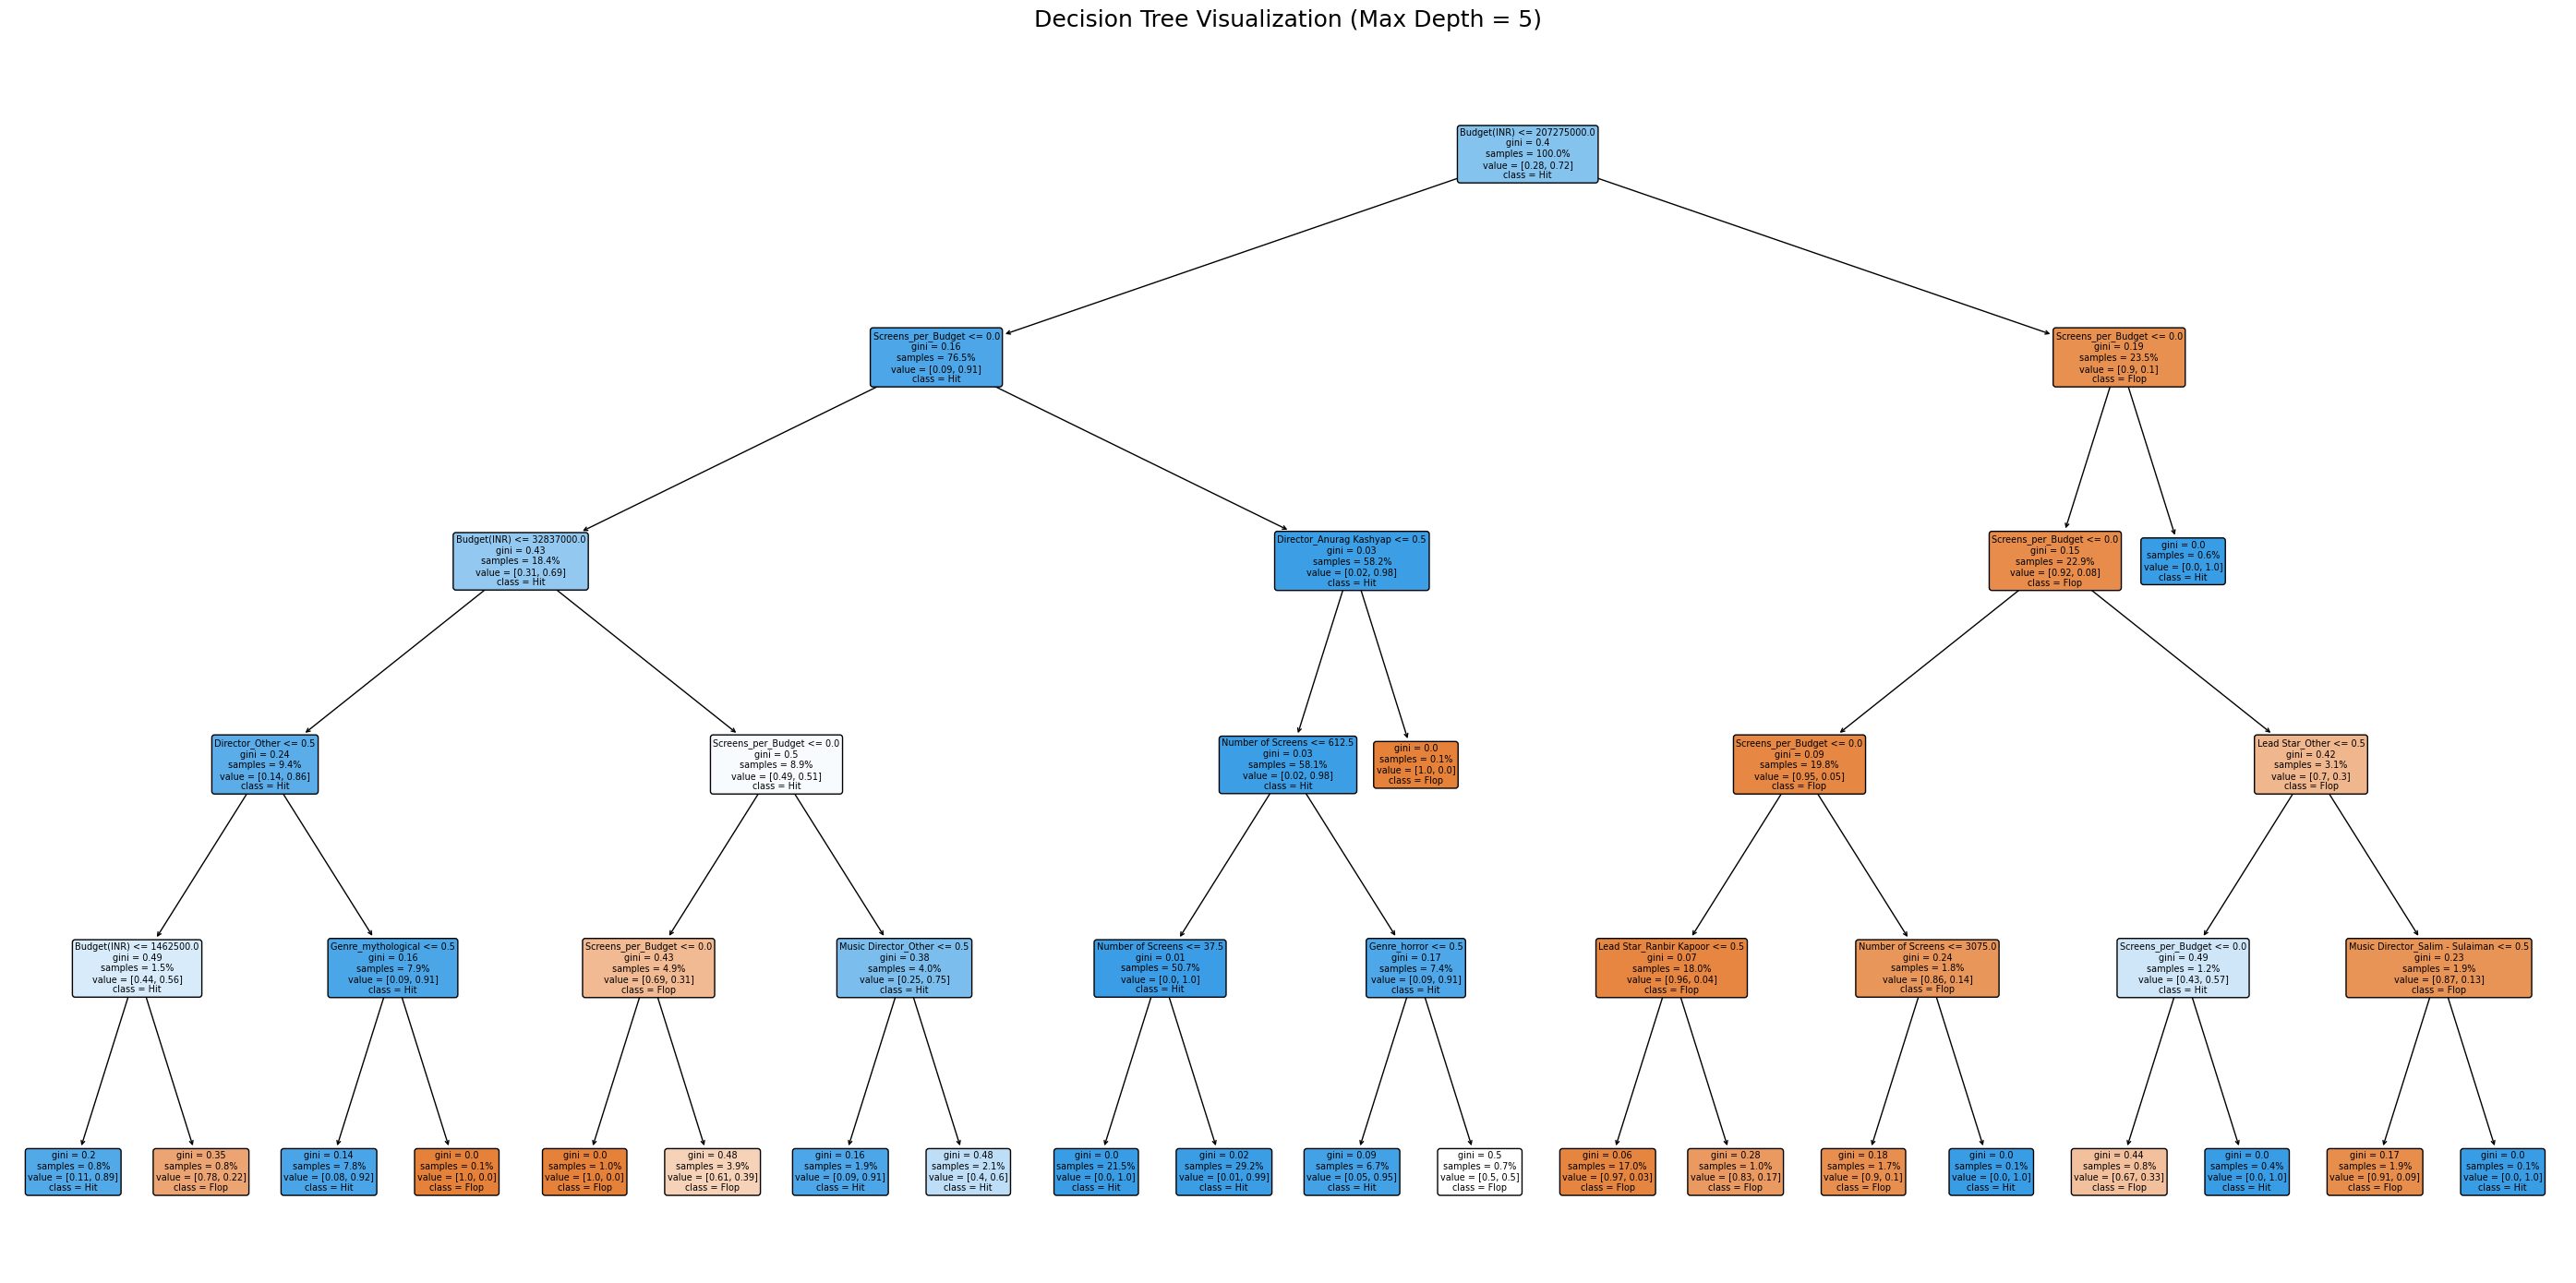

In [186]:
#  Decision Tree Visualization 

plt.figure(figsize=(28, 14))  

plot_tree(
    dt_model,
    filled=True,
    feature_names=X_encoded.columns,
    class_names=['Flop', 'Hit'],
    rounded=True,
    fontsize=7,              
    proportion=True,         
    precision=2              
)

plt.title("Decision Tree Visualization (Max Depth = 5)", fontsize=18, pad=20)
plt.tight_layout()
plt.show()


### Feature Importance Analysis
We extracted feature importance scores to identify:
- Most influential predictors
- Financial vs non-financial impact
- Key drivers of box office success

This provides business insight beyond prediction.

## Feature Importance Interpretation

The feature importance plot shows the top 10 features that most influence the Decision Tree's predictions.

Higher importance values indicate that the feature plays a stronger role in splitting the data and determining whether a movie is classified as a hit or flop.

This helps identify which factors (such as budget, screens, or other attributes) contribute most significantly to predicting box office success.

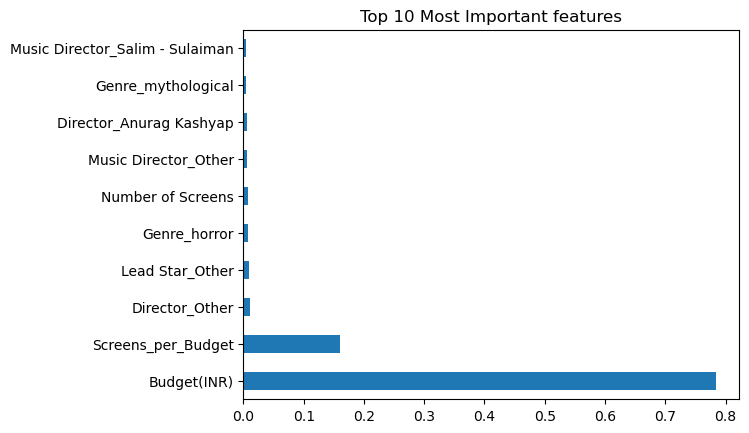

In [187]:
# Checking Feature Importance

feature_importances = pd.Series(dt_model.feature_importances_, index = X_encoded.columns)
feature_importances.nlargest(10).plot(kind = 'barh')
plt.title('Top 10 Most Important features')
plt.show()


### Evaluation
Model performance was evaluated using:
- Confusion matrix
- Precision
- Recall
- F1-score

Accuracy alone is insufficient, especially with class imbalance.  
F1-score provides a balanced measure of performance.

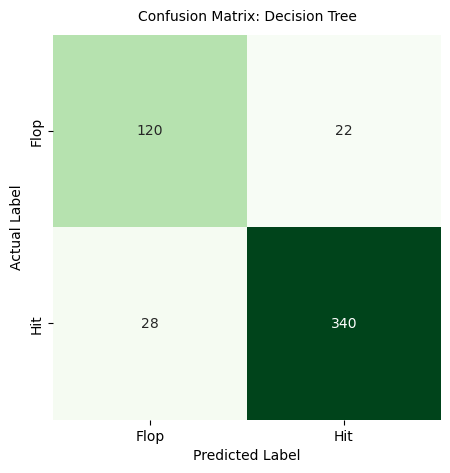


	  Classification Report


,precision,recall,f1-score,support
0,0.81,0.85,0.83,142.00
1,0.94,0.92,0.93,368.00
accuracy,0.90,0.90,0.90,0.90
macro avg,0.88,0.88,0.88,510.00
weighted avg,0.90,0.90,0.90,510.00


In [188]:
# Generating predictions on test data
y_pred = dt_model.predict(X_test)

# Creating confusion matrix to check model performance
plt.figure(figsize=(5, 5))
cm = confusion_matrix(y_test, y_pred)

# Plotting confusion matrix as heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Flop', 'Hit'], 
            yticklabels=['Flop', 'Hit'],
            cbar=False)

plt.title('Confusion Matrix: Decision Tree', fontsize=10, pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('Actual Label', fontsize=10)
plt.show()

# Generating classification report (precision, recall, f1-score)
report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("\n\t  Classification Report")
display(report_df.style.background_gradient(cmap='YlGn').format(precision=2))

## Confusion Matrix Interpretation

The confusion matrix shows how well the model predicts whether a movie is a **Hit** or a **Flop**.

Each cell represents:

- **True Positives (Hit predicted as Hit):** Movies correctly predicted as successful  
- **True Negatives (Flop predicted as Flop):** Movies correctly predicted as unsuccessful  
- **False Positives (Flop predicted as Hit):** Movies predicted as hits but actually flops  
- **False Negatives (Hit predicted as Flop):** Movies predicted as flops but actually hits  

A good model should have high values along the diagonal (correct predictions) and low values in the off-diagonal cells (incorrect predictions).

False negatives are especially important in this context because a successful movie predicted as a flop indicates missed opportunities. False positives indicate overestimating a movie's success.


---

# Naïve Bayes Classifier

---


### Feature Transformation
Financial features such as budget and screens contain extreme values.  
Large variance can negatively affect Gaussian Naïve Bayes.

To address this:
- Log transformation was applied to reduce skewness
- Features were scaled using standardization

This ensures numerical stability and better probability estimation.

---

In [189]:
# Create a fresh copy for Naive Bayes
X_train_nb = X_train.copy()
X_test_nb = X_test.copy()

# Log Transformation: Normalizing skewed financial distributions
# This prevents extreme outliers (like 800cr budgets) from shifting the class means
cols_to_log = ['Budget(INR)', 'Number of Screens', 'Screens_per_Budget']
for col in cols_to_log:
    X_train_nb[col] = np.log1p(X_train_nb[col])
    X_test_nb[col] = np.log1p(X_test_nb[col])

# Standardization: Ensures all features contribute equally to the probability
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_nb)
X_test_scaled = scaler.transform(X_test_nb)

#  Initialize and Train the model
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)

#  Generate Predictions
y_pred_nb = nb_model.predict(X_test_scaled)


### Model Assumptions
Gaussian Naïve Bayes assumes:
- Features follow a normal distribution
- Features are conditionally independent

While these assumptions are not fully true in practice, the model often performs well regardless.

---

In [190]:
# Creating the Naive Bayes model
nb_model = GaussianNB()
start_nb = time.time()

# Training (fitting) the model on scaled training data
nb_model.fit(X_train_scaled, y_train)
end_nb = time.time()

# Calculating total training time
nb_time = end_nb - start_nb

# Generating predictions on test data
y_pred_nb = nb_model.predict(X_test_scaled)
print(f"Naive Bayes training time: {nb_time:.6f} seconds")

Naive Bayes training time: 0.006097 seconds


### Model Training and Prediction
The model was trained on scaled training data and evaluated on test data.

We computed:
- Accuracy
- Weighted F1-score

This allows direct comparison with Decision Tree performance.

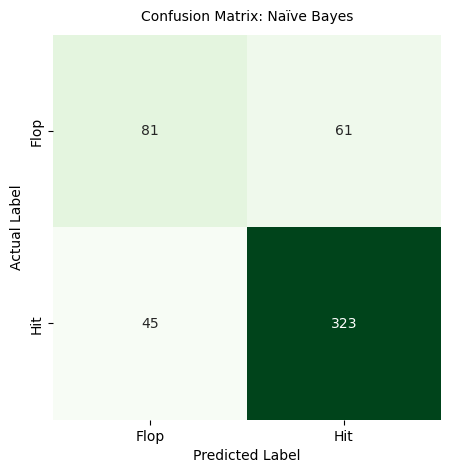


	  Classification Report (Naïve Bayes)


,precision,recall,f1-score,support
0,0.64,0.57,0.60,142.00
1,0.84,0.88,0.86,368.00
accuracy,0.79,0.79,0.79,0.79
macro avg,0.74,0.72,0.73,510.00
weighted avg,0.79,0.79,0.79,510.00


In [191]:
# Generating predictions on test data (Naïve Bayes)
y_pred_nb = nb_model.predict(X_test_scaled)

# Creating confusion matrix to check model performance
plt.figure(figsize=(5, 5))
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Plotting confusion matrix as heatmap
sns.heatmap(
    cm_nb,
    annot=True,
    fmt='d',
    cmap='Greens',
    xticklabels=['Flop', 'Hit'],
    yticklabels=['Flop', 'Hit'],
    cbar=False
)

plt.title('Confusion Matrix: Naïve Bayes', fontsize=10, pad=10)
plt.xlabel('Predicted Label', fontsize=10)
plt.ylabel('Actual Label', fontsize=10)
plt.show()

# Generating classification report (precision, recall, f1-score)
report_nb = classification_report(y_test, y_pred_nb, output_dict=True)
report_nb_df = pd.DataFrame(report_nb).transpose()

print("\n\t  Classification Report (Naïve Bayes)")
display(report_nb_df.style.background_gradient(cmap='YlGn').format(precision=2))

## Confusion Matrix Interpretation

The confusion matrix shows how well the model predicts whether a movie is a **Hit** or a **Flop**.

Each cell represents:

- **True Positives (Hit predicted as Hit):** Movies correctly predicted as successful  
- **True Negatives (Flop predicted as Flop):** Movies correctly predicted as unsuccessful  
- **False Positives (Flop predicted as Hit):** Movies predicted as hits but actually flops  
- **False Negatives (Hit predicted as Flop):** Movies predicted as flops but actually hits  

A good model should have high values along the diagonal (correct predictions) and low values in the off-diagonal cells (incorrect predictions).

False negatives are especially important in this context because a successful movie predicted as a flop indicates missed opportunities. False positives indicate overestimating a movie's success.


In [192]:
# Creating a dictionary to store evaluation metrics
results_data = {
    "Metric": ["Accuracy Score", "F1-Score (Weighted)"],
    "Decision Tree": [
        accuracy_score(y_test, y_pred), 
        f1_score(y_test, y_pred, average='weighted')
    ],
    "Naïve Bayes": [
        accuracy_score(y_test, y_pred_nb), 
        f1_score(y_test, y_pred_nb, average='weighted')
    ]
}

# Converting results into a DataFrame
df_results = pd.DataFrame(results_data)
styled_table = df_results.style.highlight_max(
    axis=1, 
    subset=["Decision Tree", "Naïve Bayes"], 
    color='green'
).format({
    "Decision Tree": "{:.4f}", 
    "Naïve Bayes": "{:.4f}"
}).set_properties(**{
    'text-align': 'center',
    'padding': '10px'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white')]}
])
display(styled_table)

,Metric,Decision Tree,Naïve Bayes
0,Accuracy Score,0.9020,0.7922
1,F1-Score (Weighted),0.9026,0.7882


##  Model Comparison

We compared Decision Tree and Naïve Bayes using:
- Accuracy
- Weighted F1-score
- Training time
- Model space
  

### Why Compare Models?
Different models capture patterns differently:
- Decision Tree captures complex interactions
- Naïve Bayes assumes independence

Comparing both helps identify:
- Which assumptions suit the dataset better
- Trade-off between interpretability and probabilistic modeling
- Robustness to noise and outliers
 beyond raw accuracy.

In [193]:
# Creating a dictionary to compare both models
results_data = {
    "Metric": [
        "Parameters Used",
        "Accuracy Score",
        "F1-Score (Weighted)",
        "Training Time(in seconds)",
        "Model Space (Object)"
        
    ],
    "Decision Tree": [
        "max_depth=5, gini",
        f"{accuracy_score(y_test, y_pred):.4f}",
        f"{f1_score(y_test, y_pred, average='weighted'):.4f}",
        dt_time,
        f"{sys.getsizeof(dt_model)} Bytes"
       
    ],
    "Naïve Bayes": [
        "Gaussian, Log-Scaled",
        f"{accuracy_score(y_test, y_pred_nb):.4f}",
        f"{f1_score(y_test, y_pred_nb, average='weighted'):.4f}",
        nb_time,
        f"{sys.getsizeof(nb_model)} Bytes"
    
    ]
}

# Converting dictionary into DataFrame
df_results = pd.DataFrame(results_data)
styled_table = df_results.style.set_properties(**{
    'background-color': '#f9f9f9',
    'color': 'black',
    'border-color': 'silver',
    'border-style': 'solid',
    'border-width': '1px',
    'text-align': 'center'
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4CAF50'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'center')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#e6f7ff')]}
]).hide(axis='index')

display(styled_table)

Metric,Decision Tree,Naïve Bayes
Parameters Used,"max_depth=5, gini","Gaussian, Log-Scaled"
Accuracy Score,0.9020,0.7922
F1-Score (Weighted),0.9026,0.7882
Training Time(in seconds),0.013758,0.006097
Model Space (Object),48 Bytes,48 Bytes


## Limitations

- Some movies contain incorrect financial values leading to label noise  
- Revenue and budget units may not be consistent across entries  
- Dataset size is relatively sma16981700 sam onlyples)  
- External factors like marketing and reviews are not included  

These limitations may affect prediction accuracy.

## Conclusion

In [194]:
print(f"""

Both models were trained to predict whether a movie is a hit or flop using pre-release features.

The Decision Tree model achieved higher performance with:
- Accuracy: {accuracy_score(y_test, y_pred):.4f}
- Weighted F1-score: {f1_score(y_test, y_pred, average='weighted'):.4f}

The Naïve Bayes model achieved:
- Accuracy: {accuracy_score(y_test, y_pred_nb):.4f}
- Weighted F1-score: {f1_score(y_test, y_pred_nb, average='weighted'):.4f}

This indicates that the Decision Tree captures patterns in the dataset more effectively.

In terms of computational performance:
- Decision Tree training time: {dt_time:.6f} seconds
- Naïve Bayes training time: {nb_time:.6f} seconds

Naïve Bayes trains faster, but since the dataset is relatively small, both models are computationally efficient.

Memory usage:
- Decision Tree model size: {sys.getsizeof(dt_model)} bytes
- Naïve Bayes model size: {sys.getsizeof(nb_model)} bytes

Overall, the Decision Tree provides better predictive performance and interpretability, making it the more suitable model for this hit/flop prediction task, while Naïve Bayes serves as a fast and useful baseline classifier.
""")



Both models were trained to predict whether a movie is a hit or flop using pre-release features.

The Decision Tree model achieved higher performance with:
- Accuracy: 0.9020
- Weighted F1-score: 0.9026

The Naïve Bayes model achieved:
- Accuracy: 0.7922
- Weighted F1-score: 0.7882

This indicates that the Decision Tree captures patterns in the dataset more effectively.

In terms of computational performance:
- Decision Tree training time: 0.013758 seconds
- Naïve Bayes training time: 0.006097 seconds

Naïve Bayes trains faster, but since the dataset is relatively small, both models are computationally efficient.

Memory usage:
- Decision Tree model size: 48 bytes
- Naïve Bayes model size: 48 bytes

Overall, the Decision Tree provides better predictive performance and interpretability, making it the more suitable model for this hit/flop prediction task, while Naïve Bayes serves as a fast and useful baseline classifier.




---
---